# ROC Curve & AUC

- ROC_Curve: plots True Positive Rate vs False Positive Rate at different thresholds
- AUC: Area Under the Curve — single number summarizing model's ability to separate classes (closer to 1 = better)
- Dataset: 50_Startups.csv
- Note: ROC/AUC need categories, but Profit is a number.
  So we convert Profit into a category: "High Profit" (1) if above the median, else "Low Profit" (0)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/50_Startups[1].csv")
df_encoded = pd.get_dummies(df, columns=["State"], drop_first=True)

# Convert Profit into a binary class: 1 = High Profit (above median), 0 = Low Profit
median_profit = df_encoded["Profit"].median()
df_encoded["High_Profit"] = (df_encoded["Profit"] > median_profit).astype(int)

X = df_encoded.drop(["Profit", "High_Profit"], axis=1)
Y = df_encoded["High_Profit"]
df_encoded.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York,High_Profit
0,165349.20,136897.80,471784.10,192261.83,False,True,1
1,162597.70,151377.59,443898.53,191792.06,False,False,1
2,153441.51,101145.55,407934.54,191050.39,True,False,1
3,144372.41,118671.85,383199.62,182901.99,False,True,1
4,142107.34,91391.77,366168.42,166187.94,True,False,1


In [3]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 40
Test size : 10


In [4]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [5]:
model = LogisticRegression()
model.fit(X_train, Y_train)

LogisticRegression()

In [6]:
Y_prob = model.predict_proba(X_test)[:, 1]

print(pd.DataFrame({"Actual": Y_test, "Probability": Y_prob}))

    Actual  Probability
13       1     0.797756
39       0     0.178290
30       0     0.247902
45       0     0.004990
17       1     0.778297
48       0     0.006604
26       0     0.433939
25       0     0.300271
32       0     0.168900
19       1     0.193777


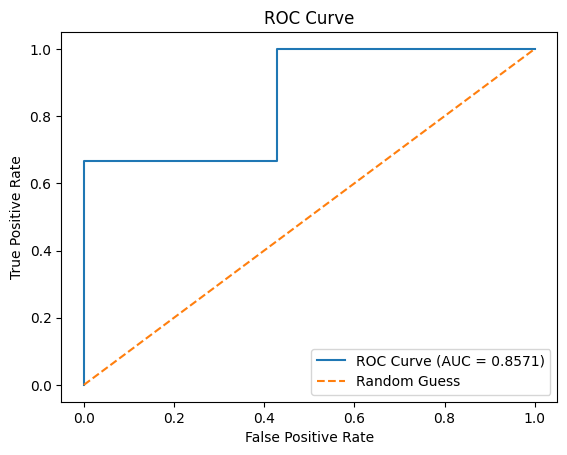

AUC Score: 0.8571


In [7]:
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)
auc = roc_auc_score(Y_test, Y_prob)

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {round(auc, 4)})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", round(auc, 4))

## Conclusion
- Profit was converted into High/Low classes (split at the median) so ROC/AUC could be used
- ROC Curve: shows the trade-off between catching positives (TPR) and false alarms (FPR) at every threshold
- A curve closer to the top-left corner means better separation between classes
- AUC: 0.5 = random guessing, 1.0 = perfect classifier
- Higher AUC means the model is better at distinguishing High Profit vs Low Profit startups

Save as ROC_AUC.ipynb
Upload to 03_Machine_Learning/04_Model_Evaluation/
